In [28]:
!pip install -q xgboost openpyxl scikit-learn

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor

# ── Output files ───────────────────────────────────────────────────────────────
SHEET_NAME  = 0
MODEL_OUT   = "relay_guard_model.pkl"
SCALER_OUT  = "scaler.pkl"
PRED_OUT    = "predictions.xlsx"

# ── Physics constants ──────────────────────────────────────────────────────────
Ea      = 0.7
k_bolt  = 8.617e-5
T_ref   = 298.15
R0      = 0.1
k_wear  = 1e-6
alpha   = 0.5

# ── HI composite weights ───────────────────────────────────────────────────────
W_DAMAGE     = 0.40
W_THERMAL    = 0.25
W_RESISTANCE = 0.25
W_CYCLES     = 0.10

# ── Forecasting ────────────────────────────────────────────────────────────────
FUTURE_STEPS = 10          # steps ahead to forecast
LAG_STEPS    = [1, 2, 3, 5, 10, 20]
ROLL_WINDOWS = [5, 10, 20, 50]

# ── XGBoost (tuned for the Δ HI regression task) ──────────────────────────────
XGB_PARAMS = {
    "n_estimators":         2000,
    "max_depth":            4,      # shallow → less overfitting on noisy Δ HI
    "learning_rate":        0.02,
    "subsample":            0.8,
    "colsample_bytree":     0.8,
    "min_child_weight":     10,     # higher → smoother predictions
    "gamma":                0.2,
    "reg_alpha":            0.1,
    "reg_lambda":           2.0,
    "random_state":         42,
    "n_jobs":               -1,
    "early_stopping_rounds": 50,
    "eval_metric":          "rmse",
}

print("✅  Imports and config ready!")

✅  Imports and config ready!


In [30]:
USE_SAMPLE_DATA = False   # ← set True to skip upload and use synthetic data

if USE_SAMPLE_DATA:
    np.random.seed(42)
    N           = 2000
    time        = np.arange(N) * 10.0
    deg         = np.linspace(0, 1, N)
    current      = (5.0  + 2.0 * np.random.randn(N) + 2.0 * deg).clip(0)
    voltage      = 230.0 + 5.0 * np.random.randn(N)
    temp         = 40.0  + 30.0 * deg + 5.0 * np.random.randn(N)
    cycles       = np.arange(N) * 3 + np.random.randint(0, 5, N)
    resistance   = (0.1 + 0.4  * deg + 0.01 * np.random.randn(N)).clip(0.05)
    peak_current = (current * (1.5 + 0.5 * np.random.rand(N))).clip(0)
    frequency    = 0.5 + 0.3 * np.random.rand(N)

    df_raw = pd.DataFrame({
        "time": time, "current": current, "voltage": voltage,
        "temp": temp, "cycles": cycles, "resistance": resistance,
        "peak_current": peak_current, "frequency": frequency,
    })
    df_raw.to_excel("relay_data.xlsx", index=False)
    DATA_FILE = "relay_data.xlsx"
    print(f"✅  Sample data generated — {N} rows")
    print(df_raw.head())
else:
    from google.colab import files
    print("📂  Upload your relay_data.xlsx …")
    uploaded  = files.upload()
    DATA_FILE = list(uploaded.keys())[0]
    print(f"✅  Uploaded: {DATA_FILE}")

📂  Upload your relay_data.xlsx …


Saving relay_data.xlsx to relay_data (1).xlsx
✅  Uploaded: relay_data (1).xlsx


In [31]:
def arrhenius_factor(T_K: pd.Series) -> pd.Series:
    return np.exp((Ea / k_bolt) * (1 / T_ref - 1 / T_K))

def compute_arc_damage(df: pd.DataFrame) -> pd.Series:
    dt  = df["time"].diff().fillna(1.0)
    T_K = df["temp"] + 273.15
    K_T = arrhenius_factor(T_K)
    return (df["current"] ** 2 * df["voltage"] * dt * K_T).cumsum()

def compute_hi_components(df: pd.DataFrame) -> pd.DataFrame:
    # HI_damage
    W      = compute_arc_damage(df)
    HI_dam = 1.0 - (W / (W.max() or 1)).clip(0, 1)
    # HI_thermal
    T_K    = df["temp"] + 273.15
    K_T    = arrhenius_factor(T_K)
    K_norm = ((K_T - K_T.min()) / (K_T.max() - K_T.min() + 1e-9)).clip(0, 1)
    HI_the = 1.0 - K_norm
    # HI_resistance
    R_mod  = R0 + k_wear * (df["cycles"] ** alpha)
    R_norm = ((R_mod - R_mod.min()) / (R_mod.max() - R_mod.min() + 1e-9)).clip(0, 1)
    HI_res = 1.0 - R_norm
    # HI_cycles
    HI_cyc = 1.0 - (df["cycles"] / (df["cycles"].max() or 1)).clip(0, 1)
    return pd.DataFrame({
        "HI_damage": HI_dam, "HI_thermal": HI_the,
        "HI_resistance": HI_res, "HI_cycles": HI_cyc,
    })

def compute_health_index(df: pd.DataFrame) -> pd.DataFrame:
    print("\n[2]  Computing Health Index …")
    hi    = compute_hi_components(df)
    df["HI"] = (W_DAMAGE*hi["HI_damage"] + W_THERMAL*hi["HI_thermal"] +
                W_RESISTANCE*hi["HI_resistance"] + W_CYCLES*hi["HI_cycles"]) * 100
    df["HI"] = df["HI"].clip(0, 100)
    df = pd.concat([df, hi], axis=1)
    print(f"     HI range: {df['HI'].min():.2f}% — {df['HI'].max():.2f}%")
    return df

print("✅  Physics / HI functions defined!")

✅  Physics / HI functions defined!


In [32]:
def rolling_slope(series: pd.Series, window: int) -> pd.Series:
    """Least-squares slope of `series` over last `window` samples."""
    def _s(y):
        if len(y) < 2: return 0.0
        x = np.arange(len(y), dtype=float); x -= x.mean()
        return float(np.dot(x, y - y.mean()) / (np.dot(x, x) + 1e-9))
    return series.rolling(window, min_periods=2).apply(_s, raw=True).fillna(0)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    print("\n[3]  Engineering features …")

    # dT/dt
    if "dT_dt" not in df.columns and "dt_dt" not in df.columns:
        dt = df["time"].diff().replace(0, np.nan)
        df["dT_dt"] = (df["temp"].diff() / dt).fillna(0)
    else:
        col = "dt_dt" if "dt_dt" in df.columns else "dT_dt"
        df.rename(columns={col: "dT_dt"}, inplace=True)

    # Cumulative arc damage
    dt   = df["time"].diff().fillna(1.0)
    T_K  = df["temp"] + 273.15
    K_T  = arrhenius_factor(T_K)
    df["damage"] = (df["current"] ** 2 * df["voltage"] * dt * K_T).cumsum()

    # Lifecycle position — lets model know where we are in the relay's life
    df["lifecycle_pos"] = np.arange(len(df)) / max(len(df) - 1, 1)

    # ── HI lag features ────────────────────────────────────────────────────────
    for lag in LAG_STEPS:
        df[f"HI_lag_{lag}"] = df["HI"].shift(lag)

    # ── HI trend features (slope = how fast HI is declining) ──────────────────
    for w in [5, 10, 20, 50]:
        df[f"HI_slope_{w}"]     = rolling_slope(df["HI"], w)
        df[f"HI_roll_mean_{w}"] = df["HI"].rolling(w, min_periods=1).mean()
        df[f"HI_roll_std_{w}"]  = df["HI"].rolling(w, min_periods=1).std().fillna(0)

    # ── Sensor rolling stats ───────────────────────────────────────────────────
    for col in ["current", "temp", "resistance", "voltage"]:
        if col not in df.columns: continue
        for w in ROLL_WINDOWS:
            df[f"{col}_rmean_{w}"] = df[col].rolling(w, min_periods=1).mean()
            df[f"{col}_rstd_{w}"]  = df[col].rolling(w, min_periods=1).std().fillna(0)

    # ── Interaction features ───────────────────────────────────────────────────
    df["damage_x_temp"]    = df["damage"]    * df["temp"]
    df["current_x_resist"] = df["current"]   * df["resistance"]
    df["hi_x_cycles"]      = df["HI"]        * df["cycles"]
    df["hi_slope_x_dmg"]   = df["HI_slope_10"] * df["damage"]   # fast-declining + heavy damage

    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"     Columns: {df.shape[1]}  |  Rows after NaN drop: {len(df)}")
    return df

In [33]:
def create_target(df: pd.DataFrame, steps: int = FUTURE_STEPS) -> pd.DataFrame:
    print(f"\n[4]  Creating Δ HI target ({steps} steps ahead) …")
    df["HI_future"]  = df["HI"].shift(-steps)
    df["delta_HI"]   = df["HI_future"] - df["HI"]   # ← the NEW target
    df.dropna(subset=["delta_HI"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"     delta_HI stats: mean={df['delta_HI'].mean():.3f}  "
          f"std={df['delta_HI'].std():.3f}  "
          f"min={df['delta_HI'].min():.3f}  "
          f"max={df['delta_HI'].max():.3f}")
    print(f"     Rows: {len(df)}")
    return df


def build_feature_cols(df: pd.DataFrame):
    EXCLUDE = {"HI_future", "delta_HI", "Alert", "time"}
    return [c for c in df.columns if c not in EXCLUDE], "delta_HI"

print("✅  Feature engineering & target functions defined!")

✅  Feature engineering & target functions defined!


In [34]:
def classify_alert(hi_value: float) -> str:
    if hi_value > 70:   return "✅ Healthy"
    elif hi_value > 40: return "⚠️  Warning"
    elif hi_value > 20: return "🔴 Critical"
    else:               return "🚨 Failure Imminent"


def train_model(df: pd.DataFrame):
    """
    Train on Δ HI target with walk-forward evaluation.
    Final model is trained on ALL data so it can handle the full degradation lifecycle.
    """
    print("\n[5]  Training XGBoost on Δ HI …")
    feat_cols, target_col = build_feature_cols(df)

    X = df[feat_cols].values
    y = df[target_col].values                        # Δ HI values

    scaler   = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    # ── Walk-forward split: 80 % train / 20 % test ────────────────────────────
    split    = int(len(X) * 0.80)
    X_tr, X_te = X_scaled[:split], X_scaled[split:]
    y_tr, y_te = y[:split],        y[split:]
    hi_te       = df["HI"].values[split:]            # actual HI for the test rows

    print(f"     Train: {len(X_tr)} rows  |  Test: {len(X_te)} rows")

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_tr, y_tr,
              eval_set=[(X_tr, y_tr), (X_te, y_te)],
              verbose=100)
    print(f"     Best iteration: {model.best_iteration}")

    # ── Predict Δ HI, then reconstruct absolute HI ────────────────────────────
    delta_pred    = model.predict(X_te)
    hi_pred       = (hi_te + delta_pred).clip(0, 100)   # HI_future = HI + Δ HI
    hi_actual     = df["HI_future"].values[split:]

    # ── Metrics on reconstructed HI ───────────────────────────────────────────
    mae  = mean_absolute_error(hi_actual, hi_pred)
    rmse = np.sqrt(mean_squared_error(hi_actual, hi_pred))
    r2   = r2_score(hi_actual, hi_pred)

    print(f"\n     ── Evaluation (absolute HI after Δ reconstruction) ──────")
    print(f"     MAE      : {mae:.4f}%")
    print(f"     RMSE     : {rmse:.4f}%")
    print(f"     R²       : {r2:.4f}")
    print(f"     Pred std : {hi_pred.std():.4f}   Target std: {hi_actual.std():.4f}")
    print(f"     Pred min/max: {hi_pred.min():.2f} / {hi_pred.max():.2f}")
    print(f"     ────────────────────────────────────────────────────────")

    return model, scaler, feat_cols, X_te, hi_te, hi_actual, hi_pred


def plot_results(hi_actual, hi_pred, hi_te, feature_cols, model):
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle("RelayGuard ML v3 — Training Results (Δ HI model)",
                 fontsize=14, fontweight="bold")

    # Panel 1: Actual vs Predicted HI
    axes[0].plot(hi_actual, label="Actual HI",    color="#2196F3", linewidth=1.5)
    axes[0].plot(hi_pred,   label="Predicted HI", color="#FF5722",
                 linewidth=1.5, linestyle="--", alpha=0.85)
    axes[0].axhline(70, color="green",  linestyle=":", linewidth=1, label="Healthy (70%)")
    axes[0].axhline(40, color="orange", linestyle=":", linewidth=1, label="Warning (40%)")
    axes[0].axhline(20, color="red",    linestyle=":", linewidth=1, label="Critical (20%)")
    axes[0].set_title("Actual vs Predicted HI (test set)")
    axes[0].set_xlabel("Sample"); axes[0].set_ylabel("Health Index (%)")
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    # Panel 2: Residuals
    res = hi_pred - hi_actual
    axes[1].scatter(hi_actual, res, alpha=0.4, color="#7C4DFF", s=8)
    axes[1].axhline(0, color="red", linewidth=1)
    axes[1].set_title("Residuals vs Actual HI\n(good = scatter around 0)")
    axes[1].set_xlabel("Actual HI (%)"); axes[1].set_ylabel("Residual (%)")
    axes[1].grid(alpha=0.3)

    # Panel 3: Feature importance
    imp        = model.feature_importances_
    sidx       = np.argsort(imp)[::-1][:20]
    axes[2].barh([feature_cols[i] for i in sidx[::-1]],
                  imp[sidx[::-1]], color="#03DAC6")
    axes[2].set_title("Feature Importance (Top 20)")
    axes[2].set_xlabel("Importance Score"); axes[2].grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("     Plot saved → training_results.png")

print("✅  Training & plotting functions defined!")


✅  Training & plotting functions defined!


  RelayGuard ML Training Pipeline  v3

[1]  Loading: relay_data (1).xlsx
     Shape: (3000, 8) | Columns: ['time', 'current', 'voltage', 'temp', 'cycles', 'resistance', 'peak_current', 'frequency']

[2]  Computing Health Index …
     HI range: 4.31% — 99.87%

[3]  Engineering features …
     Columns: 70  |  Rows after NaN drop: 2980

[4]  Creating Δ HI target (10 steps ahead) …
     delta_HI stats: mean=-0.255  std=1.356  min=-27.364  max=22.009
     Rows: 2970

[5]  Training XGBoost on Δ HI …
     Train: 2376 rows  |  Test: 594 rows
[0]	validation_0-rmse:0.92232	validation_1-rmse:2.39663
[100]	validation_0-rmse:0.69973	validation_1-rmse:2.34360
[195]	validation_0-rmse:0.63738	validation_1-rmse:2.31256
     Best iteration: 145

     ── Evaluation (absolute HI after Δ reconstruction) ──────
     MAE      : 1.0663%
     RMSE     : 2.2837%
     R²       : 0.9145
     Pred std : 7.2222   Target std: 7.8086
     Pred min/max: 10.20 / 49.58
     ──────────────────────────────────────────────

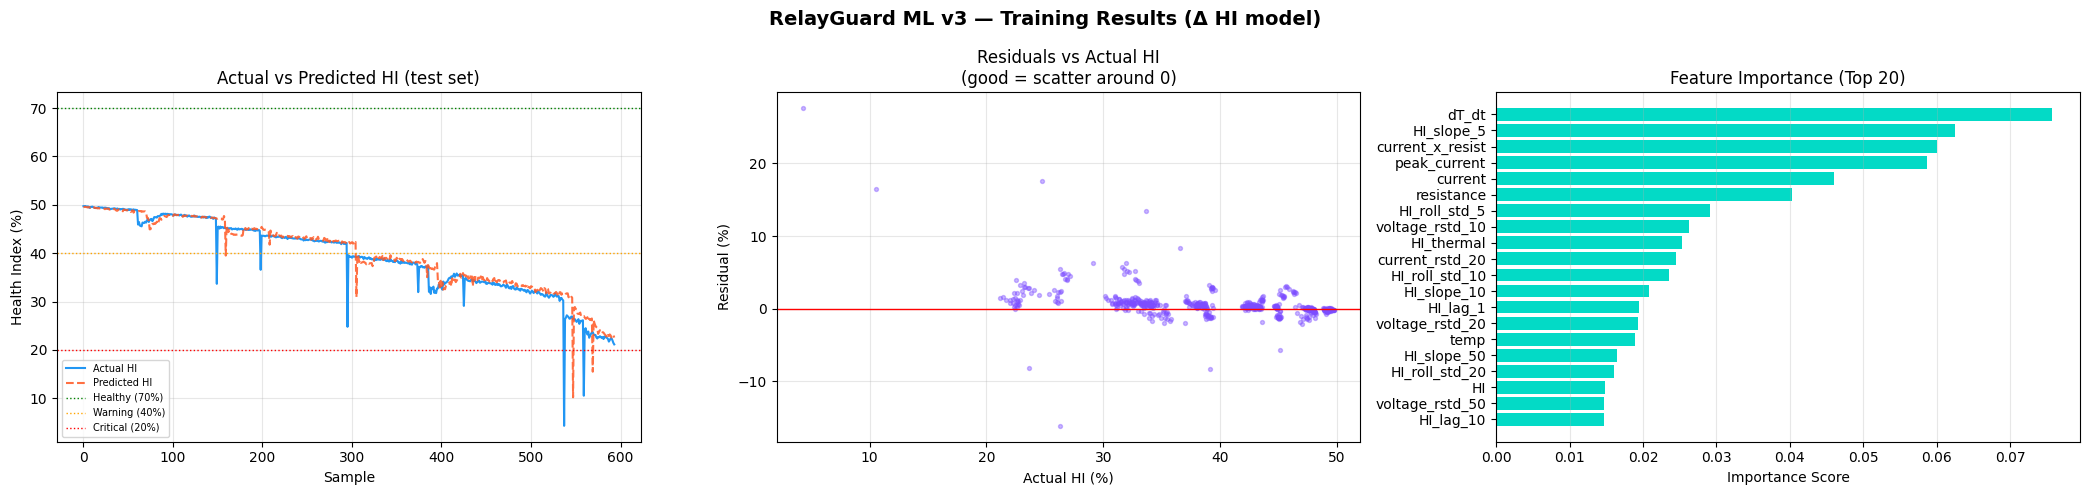

     Plot saved → training_results.png

  Training complete! ✅


In [35]:
print("=" * 60)
print("  RelayGuard ML Training Pipeline  v3")
print("=" * 60)

# 1. Load
print(f"\n[1]  Loading: {DATA_FILE}")
df = pd.read_excel(DATA_FILE, sheet_name=SHEET_NAME)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print(f"     Shape: {df.shape} | Columns: {list(df.columns)}")

# 2. Health Index
df = compute_health_index(df)

# 3. Feature engineering
df = engineer_features(df)

# 4. Δ HI target
df = create_target(df, steps=FUTURE_STEPS)

# 5. Train
model, scaler, feat_cols, X_te, hi_te, hi_actual, hi_pred = train_model(df)

# 6. Sample predictions
print("\n[6]  Sample predictions (test set):")
print(f"     {'Actual HI':>10} {'Predicted HI':>14} {'Alert':>22}")
print(f"     {'-'*52}")
for a, p in zip(hi_actual[:15], hi_pred[:15]):
    print(f"     {a:>10.2f}%  {p:>12.2f}%   {classify_alert(p)}")

# 7. Save model & scaler
joblib.dump(model,  MODEL_OUT)
joblib.dump(scaler, SCALER_OUT)
print(f"\n[7]  Model saved  → {MODEL_OUT}")
print(f"     Scaler saved → {SCALER_OUT}")

# 8. Save predictions xlsx
n      = len(hi_pred)
result = df.tail(n).copy().reset_index(drop=True)
result["HI_predicted"] = hi_pred
result["HI_actual"]    = hi_actual
result["error_%"]      = hi_pred - hi_actual
result["Alert"]        = result["HI_predicted"].apply(classify_alert)
result.to_excel(PRED_OUT, index=False)
print(f"     Predictions saved → {PRED_OUT}")

# 9. Plot
plot_results(hi_actual, hi_pred, hi_te, feat_cols, model)

print("\n" + "=" * 60)
print("  Training complete! ✅")
print("=" * 60)

In [37]:

from google.colab import files
for fname in [MODEL_OUT, SCALER_OUT, PRED_OUT, "training_results.png"]:
    try:
        files.download(fname)
        print(f"⬇️   Downloading {fname} …")
    except Exception as e:
        print(f"⚠️   Could not download {fname}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️   Downloading relay_guard_model.pkl …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️   Downloading predictions.xlsx …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️   Downloading training_results.png …
